In [26]:
# Spark setup for EDA
from pyspark.sql import SparkSession

try:
    spark
except NameError:
    spark = None

if spark is None:
    spark = (
        SparkSession.builder
        .appName("Fraud EDA")
        .master("local[*]")
        .config("spark.sql.repl.eagerEval.enabled", True)
        .config("spark.sql.parquet.cacheMetadata", "true")
        .config("spark.sql.session.timeZone", "Etc/UTC")
        .config("spark.driver.memory", "8g")
        .config("spark.executor.memory", "8g")
        .config("spark.driver.maxResultSize", "2g")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .config("spark.sql.shuffle.partitions", "64")
        .config("spark.default.parallelism", "64")
        .getOrCreate()
    )


In [27]:
# Load curated dataset (joined_dataset)
from pyspark.sql import functions as F

curated_path = "data/curated/joined_dataset"
df = spark.read.parquet(curated_path)

# Ensure consumer fraud prob is double and create a 0-1 scaled version if data is 0-100
if df.select(F.max("con_fraud_prob")).first()[0] and df.select(F.max("con_fraud_prob")).first()[0] > 1.0:
    df = df.withColumn("con_fraud_prob01", (F.col("con_fraud_prob") / 100.0))
else:
    df = df.withColumn("con_fraud_prob01", F.col("con_fraud_prob"))

df.select("con_fraud_prob", "con_fraud_prob01").summary("count", "min", "approx_count_distinct", "mean", "stddev", "25%", "50%", "75%", "max").show(truncate=False)


+---------------------+------------------+-------------------+
|summary              |con_fraud_prob    |con_fraud_prob01   |
+---------------------+------------------+-------------------+
|count                |40423             |40423              |
|min                  |8.287143531552802 |0.08287143531552803|
|approx_count_distinct|24325             |23127              |
|mean                 |14.802273487813174|0.14802273487813172|
|stddev               |9.502325872690063 |0.09502325872690062|
|25%                  |9.556621834543654 |0.09556621834543653|
|50%                  |11.568545798247202|0.11568545798247203|
|75%                  |15.933401981892036|0.15933401981892037|
|max                  |97.6298077657765  |0.976298077657765  |
+---------------------+------------------+-------------------+



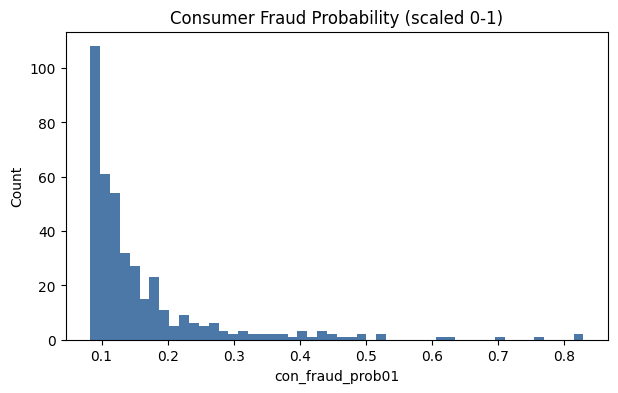

In [28]:
# Plot histogram of consumer fraud probability (sample to Pandas)
import matplotlib.pyplot as plt

sample = df.select("con_fraud_prob01").dropna().sample(False, 0.01, seed=42).toPandas()
plt.figure(figsize=(7,4))
plt.hist(sample["con_fraud_prob01"], bins=50, color="#4C78A8")
plt.title("Consumer Fraud Probability (scaled 0-1)")
plt.xlabel("con_fraud_prob01")
plt.ylabel("Count")
plt.show()


In [29]:
# Correlations with numeric features
numeric_cols = [
    c for c, t in df.dtypes
    if t in ("int", "bigint", "double", "float") and c not in {"con_fraud_prob", "con_fraud_prob01"}
]

corrs = []
for c in numeric_cols:
    try:
        cor = df.stat.corr(c, "con_fraud_prob01")
        if cor is not None:
            corrs.append((c, cor))
    except Exception:
        pass

# Show top absolute correlations
corrs_sorted = sorted(corrs, key=lambda x: abs(x[1]), reverse=True)[:20]
for c, v in corrs_sorted:
    print(f"{c}: {v:.4f}")


dollar_value: 0.0046
merch_fraud_prob: 0.0044
user_id: -0.0005
merchant_abn: -0.0004


In [30]:
# Simple logistic regression on a weak label from con_fraud_prob01
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# Create a binary label by thresholding prob at its 95th percentile among non-null
q95 = df.select(F.percentile_approx("con_fraud_prob01", 0.95)).first()[0]
model_df = (
    df
    .withColumn("label", (F.col("con_fraud_prob01") >= F.lit(q95)).cast("double"))
    .dropna(subset=["label"])  # ensure label exists
)

# Select a few candidate features (expand as needed)
# Note: strings like rev_band, biz_tags need encoding
cat_cols = ["rev_band"]
num_cols = ["dollar_value"]

stages = []
for c in cat_cols:
    idx = StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    ohe = OneHotEncoder(inputCols=[f"{c}_idx"], outputCols=[f"{c}_ohe"]) 
    stages += [idx, ohe]

assembler = VectorAssembler(
    inputCols=["dollar_value"] + [f"{c}_ohe" for c in cat_cols],
    outputCol="features"
)

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20)

pipeline = Pipeline(stages=stages + [assembler, lr])
train, test = model_df.sampleBy("label", fractions={0.0: 0.1, 1.0: 1.0}, seed=42).randomSplit([0.8, 0.2], seed=42)
mdl = pipeline.fit(train)

pred = mdl.transform(test)
pred.select("label", "probability", "prediction").show(10, truncate=False)

# Print coefficients for interpretability (use the fitted model class)
from pyspark.ml.classification import LogisticRegressionModel
lr_model = next((s for s in mdl.stages if isinstance(s, LogisticRegressionModel)), None)
if lr_model is None:
    print("LR model stage not found. Stages:", [type(s).__name__ for s in mdl.stages])
else:
    print("Intercept:", lr_model.intercept)
    print("Coefficients:", lr_model.coefficients)


+-----+----------------------------------------+----------+
|label|probability                             |prediction|
+-----+----------------------------------------+----------+
|1.0  |[0.6442890375619901,0.3557109624380099] |0.0       |
|0.0  |[0.6349956837050205,0.36500431629497954]|0.0       |
|0.0  |[0.6558251428643395,0.34417485713566054]|0.0       |
|0.0  |[0.6451123987665341,0.35488760123346585]|0.0       |
|0.0  |[0.6475564084594949,0.3524435915405051] |0.0       |
|1.0  |[0.6543623930644225,0.34563760693557755]|0.0       |
|1.0  |[0.6706483553774873,0.32935164462251265]|0.0       |
|0.0  |[0.68864824693963,0.31135175306037]     |0.0       |
|0.0  |[0.6519386869707855,0.3480613130292145] |0.0       |
|0.0  |[0.6324236575561158,0.36757634244388415]|0.0       |
+-----+----------------------------------------+----------+
only showing top 10 rows
Intercept: -0.5799901547290616
Coefficients: [-0.0005843747376674907,0.0018120369600510592,0.052475086278919975,-0.045294106035274,0.14

In [31]:
# Parameters and load fraud delta file (set delta_path accordingly)
import os
from pyspark.sql import functions as F
from pyspark.sql.functions import to_date

# TODO: set this to your actual delta file path (CSV or Parquet)
# e.g., "data/tables/transaction_data/fraud_delta.csv"
delta_path = "data/tables/merchant_data/consumer_fraud_probability.csv"

if not delta_path:
    raise ValueError("Set delta_path to the fraud delta file location (CSV or Parquet).")

ext = os.path.splitext(delta_path)[1].lower()
if ext == ".csv":
    delta_raw = spark.read.option("header", True).option("inferSchema", True).csv(delta_path)
elif ext == ".parquet":
    delta_raw = spark.read.parquet(delta_path)
else:
    raise ValueError(f"Unsupported delta file extension: {ext}")

# Normalize column names to lower-case for matching
delta = delta_raw
for c in delta.columns:
    delta = delta.withColumnRenamed(c, c.lower())

# Create order_date if order_datetime exists
if "order_datetime" in delta.columns and "order_date" not in delta.columns:
    delta = delta.withColumn("order_date", to_date("order_datetime"))

# Try to standardize possible label column
label_col = None
for cand in ["is_fraud", "fraud", "label"]:
    if cand in delta.columns:
        label_col = cand
        break

if label_col:
    delta = delta.withColumn("is_fraud", F.col(label_col).cast("boolean"))
else:
    # If no label column exists, presence in delta implies fraud
    delta = delta.withColumn("is_fraud", F.lit(True))

delta.select(*delta.columns[:10]).show(5, truncate=False)

+-------+--------------+-----------------+----------+--------+
|user_id|order_datetime|fraud_probability|order_date|is_fraud|
+-------+--------------+-----------------+----------+--------+
|6228   |2021-12-19    |97.6298077657765 |2021-12-19|true    |
|21419  |2021-12-10    |99.24738020302328|2021-12-10|true    |
|5606   |2021-10-17    |84.05825045251777|2021-10-17|true    |
|3101   |2021-04-17    |91.42192091901347|2021-04-17|true    |
|22239  |2021-10-19    |94.70342477508035|2021-10-19|true    |
+-------+--------------+-----------------+----------+--------+
only showing top 5 rows


In [32]:
# Join delta to curated data to derive is_fraud on transactions
curated = spark.read.parquet("data/curated/joined_dataset")
curated = curated.withColumn("order_date", to_date("order_datetime"))

# Prefer join on order_id if available in delta; otherwise fallback to (user_id, order_date)
join_df = curated
if "order_id" in delta.columns and "order_id" in curated.columns:
    join_keys = ["order_id"]
    join_df = join_df.join(delta.select("order_id", "is_fraud"), on="order_id", how="left")
else:
    # normalize id types
    join_df = join_df.withColumn("user_id_str", F.col("user_id").cast("string"))
    delta_keys = delta
    if "user_id" in delta.columns:
        delta_keys = delta_keys.withColumn("user_id_str", F.col("user_id").cast("string"))
    if "order_date" not in delta_keys.columns and "order_datetime" in delta_keys.columns:
        delta_keys = delta_keys.withColumn("order_date", to_date("order_datetime"))
    join_keys = ["user_id_str", "order_date"]
    join_df = join_df.join(delta_keys.select("user_id_str", "order_date", "is_fraud"), on=join_keys, how="left")

# default non-matches to False
labeled_tx = join_df.withColumn("is_fraud", F.coalesce(F.col("is_fraud"), F.lit(False))).drop("user_id_str")

labeled_tx.groupBy("is_fraud").count().show()


+--------+--------+
|is_fraud|   count|
+--------+--------+
|   false|12894007|
|    true|   40629|
+--------+--------+



In [33]:
# EDA: compare distributions and simple frequency feature
# Per-user purchase count as a crude "frequency" proxy
from pyspark.sql.window import Window

w_user = Window.partitionBy("user_id")
edf = labeled_tx.withColumn("user_txn_count", F.count("*").over(w_user))

# Fraud rate by user frequency bins
edf = edf.withColumn("freq_bin", F.when(F.col("user_txn_count") <= 2, "<=2")
                               .when(F.col("user_txn_count") <= 5, "3-5")
                               .when(F.col("user_txn_count") <= 10, "6-10")
                               .otherwise(">10"))

fraud_by_bin = edf.groupBy("freq_bin").agg(
    F.count("*").alias("n"),
    F.avg(F.col("is_fraud").cast("int")).alias("fraud_rate")
).orderBy("n", ascending=False)
fraud_by_bin.show(truncate=False)

# Dollar value distribution by label (approx quantiles)
for lbl in [True, False]:
    qs = edf.where(F.col("is_fraud") == lbl).approxQuantile("dollar_value", [0.25, 0.5, 0.75, 0.9, 0.99], 0.01)
    print(lbl, qs)


+--------+--------+---------------------+
|freq_bin|n       |fraud_rate           |
+--------+--------+---------------------+
|>10     |12934636|0.0031411011488842824|
+--------+--------+---------------------+



True [26.029408577612323, 61.54016177256408, 142.3610255582616, 287.67094910556654, 1187.6914138614413]


False [23.61548440738826, 55.57355477712753, 126.04818425637245, 247.0340710646031, 1193.7571383299048]


In [34]:
# Simple model using true is_fraud from delta
default_features = ["dollar_value", "user_txn_count"]

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

mdf = edf.select(*(default_features + ["is_fraud"]))
mdf = mdf.fillna({"dollar_value": 0.0, "user_txn_count": 0})

assembler = VectorAssembler(inputCols=default_features, outputCol="features")
mdf2 = assembler.transform(mdf).select("features", F.col("is_fraud").cast("double").alias("label"))

train, test = mdf2.randomSplit([0.8, 0.2], seed=42)
lr = LogisticRegression(maxIter=20)
model = lr.fit(train)

pred = model.transform(test)
auc = BinaryClassificationEvaluator(metricName="areaUnderROC").evaluate(pred)
print("AUC:", auc)

pred.select("label", "probability", "prediction").show(10, truncate=False)


AUC: 0.527313889302009


+-----+------------------------------------------+----------+
|label|probability                               |prediction|
+-----+------------------------------------------+----------+
|0.0  |[0.9971519233446174,0.0028480766553825587]|0.0       |
|0.0  |[0.9971520861401036,0.002847913859896356] |0.0       |
|0.0  |[0.997152663528822,0.0028473364711779636] |0.0       |
|0.0  |[0.9971514124085187,0.002848587591481322] |0.0       |
|0.0  |[0.9971524860500737,0.002847513949926328] |0.0       |
|0.0  |[0.9971526498710165,0.002847350128983517] |0.0       |
|0.0  |[0.9971525498723588,0.0028474501276412045]|0.0       |
|0.0  |[0.9971529610291665,0.002847038970833493] |0.0       |
|0.0  |[0.9971507882056938,0.0028492117943061945]|0.0       |
|0.0  |[0.9971539401870848,0.0028460598129151915]|0.0       |
+-----+------------------------------------------+----------+
only showing top 10 rows


In [35]:
# User-level aggregation model: avg transaction value and txn count
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Ensure we have transaction-level labels in labeled_tx
# Aggregate to user-level features and label (any fraud for the user)
user_df = labeled_tx.groupBy("user_id").agg(
    F.avg("dollar_value").alias("avg_dollar_value"),
    F.count("*").alias("txn_count"),
    F.max(F.col("is_fraud").cast("int")).alias("label")
)

# Basic cleaning
user_df = user_df.fillna({"avg_dollar_value": 0.0, "txn_count": 0}).withColumn("label", F.col("label").cast("double"))

# Assemble features
assembler = VectorAssembler(inputCols=["avg_dollar_value", "txn_count"], outputCol="features")
user_feat = assembler.transform(user_df).select("features", "label")

# Train/test split
train_u, test_u = user_feat.randomSplit([0.8, 0.2], seed=42)

# Same model family: Logistic Regression
lr_u = LogisticRegression(maxIter=30)
mdl_u = lr_u.fit(train_u)

pred_u = mdl_u.transform(test_u)
auc_u = BinaryClassificationEvaluator(metricName="areaUnderROC").evaluate(pred_u)
print("User-level AUC:", auc_u)

pred_u.select("label", "probability", "prediction").show(10, truncate=False)


User-level AUC: 0.5283995095818375


+-----+----------------------------------------+----------+
|label|probability                             |prediction|
+-----+----------------------------------------+----------+
|1.0  |[0.26839175081827216,0.7316082491817278]|1.0       |
|1.0  |[0.2671851677085714,0.7328148322914285] |1.0       |
|0.0  |[0.27738410687364856,0.7226158931263514]|1.0       |
|0.0  |[0.2744551823805231,0.725544817619477]  |1.0       |
|1.0  |[0.2767216694768012,0.7232783305231988] |1.0       |
|1.0  |[0.2771777646054622,0.7228222353945378] |1.0       |
|0.0  |[0.27757625768124544,0.7224237423187545]|1.0       |
|1.0  |[0.2782181381352312,0.7217818618647688] |1.0       |
|0.0  |[0.28106023716671674,0.7189397628332832]|1.0       |
|1.0  |[0.28356390890142125,0.7164360910985788]|1.0       |
+-----+----------------------------------------+----------+
only showing top 10 rows


In [36]:
# User-level feature engineering: recency, variability, merchant diversity
from pyspark.sql import functions as F
from pyspark.sql.functions import datediff

# Snapshot date to compute recency/tenure
snap = labeled_tx.agg(F.max("order_datetime").alias("snap")).first()["snap"]

# Core user aggregates
user_feats = labeled_tx.groupBy("user_id").agg(
    F.count("*").alias("txn_count"),
    F.avg("dollar_value").alias("avg_dollar_value"),
    F.stddev_samp("dollar_value").alias("std_dollar_value"),
    F.expr("percentile_approx(dollar_value, 0.5)").alias("median_dollar_value"),
    F.max("dollar_value").alias("max_dollar_value"),
    F.countDistinct("merchant_abn").alias("merchant_diversity"),
    F.max("order_datetime").alias("last_txn_date"),
    F.min("order_datetime").alias("first_txn_date")
)

user_feats = (
    user_feats
    .withColumn("recency_days", datediff(F.lit(snap), F.col("last_txn_date")))
    .withColumn("tenure_days", datediff(F.lit(snap), F.col("first_txn_date")))
    .drop("last_txn_date", "first_txn_date")
)

# User-level label: any fraud for the user
user_label = labeled_tx.groupBy("user_id").agg(F.max(F.col("is_fraud").cast("int")).alias("label"))

user_wide = (
    user_feats.join(user_label, on="user_id", how="left")
    .fillna({"label": 0, "std_dollar_value": 0.0})
    .withColumn("label", F.col("label").cast("double"))
)

user_wide.select("label", "avg_dollar_value", "txn_count", "std_dollar_value", "merchant_diversity", "recency_days", "tenure_days").show(5, truncate=False)


+-----+------------------+---------+------------------+------------------+------------+-----------+
|label|avg_dollar_value  |txn_count|std_dollar_value  |merchant_diversity|recency_days|tenure_days|
+-----+------------------+---------+------------------+------------------+------------+-----------+
|1.0  |108.1692423450446 |540      |122.96481448239231|320               |0           |605        |
|0.0  |103.61491584449973|524      |120.3864001592684 |313               |3           |602        |
|0.0  |101.2343555440012 |546      |122.24158479419832|318               |3           |604        |
|1.0  |103.93664273041624|539      |115.18489063232595|317               |1           |605        |
|1.0  |104.73874896658917|552      |121.3533021662321 |319               |0           |605        |
+-----+------------------+---------+------------------+------------------+------------+-----------+
only showing top 5 rows


In [37]:
# Weighted logistic regression on engineered user features
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

feat_cols = [
    "avg_dollar_value", "txn_count", "std_dollar_value",
    "median_dollar_value", "max_dollar_value", "merchant_diversity",
    "recency_days", "tenure_days"
]

# Compute class weights to handle imbalance
class_counts = user_wide.groupBy("label").count().collect()
count_dict = {int(r["label"]): r["count"] for r in class_counts}
neg = float(count_dict.get(0, 1))
pos = float(count_dict.get(1, 1))
pos_weight = neg / max(pos, 1.0)

user_wide_w = user_wide.withColumn("weight", F.when(F.col("label") == 1.0, pos_weight).otherwise(1.0))

assembler = VectorAssembler(inputCols=feat_cols, outputCol="features")
df_feat = assembler.transform(user_wide_w).select("features", "label", "weight")

train_w, test_w = df_feat.randomSplit([0.8, 0.2], seed=42)
lr_w = LogisticRegression(maxIter=50, weightCol="weight")
mdl_w = lr_w.fit(train_w)

pred_w = mdl_w.transform(test_w)
roc_auc = BinaryClassificationEvaluator(metricName="areaUnderROC").evaluate(pred_w)
pr_auc = BinaryClassificationEvaluator(metricName="areaUnderPR").evaluate(pred_w)
print("Weighted LR ROC AUC:", roc_auc)
print("Weighted LR PR AUC:", pr_auc)

pred_w.select("label", "probability", "prediction").show(10, truncate=False)


Weighted LR ROC AUC: 0.5137754880620924
Weighted LR PR AUC: 0.6804886986888041


+-----+----------------------------------------+----------+
|label|probability                             |prediction|
+-----+----------------------------------------+----------+
|1.0  |[0.4434033769817611,0.5565966230182389] |1.0       |
|1.0  |[0.4647756206499128,0.5352243793500873] |1.0       |
|1.0  |[0.458063939416967,0.541936060583033]   |1.0       |
|1.0  |[0.46047394798757746,0.5395260520124225]|1.0       |
|1.0  |[0.4692551847728339,0.5307448152271661] |1.0       |
|1.0  |[0.44474565617337963,0.5552543438266204]|1.0       |
|1.0  |[0.47134618615483426,0.5286538138451657]|1.0       |
|0.0  |[0.45873424678983316,0.5412657532101668]|1.0       |
|1.0  |[0.46344970350676584,0.5365502964932342]|1.0       |
|1.0  |[0.4724757466364312,0.5275242533635688] |1.0       |
+-----+----------------------------------------+----------+
only showing top 10 rows
